# UAS Bengkel Koding Data Science
##Nama : Gabriella Jovanka Bustan
##NIM : A11.2023.14861

Dataset: `sales_marketing_customer_dataset.csv`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load Dataset
df = pd.read_csv('sales_marketing_customer_dataset.csv')
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


### 1. Eksplorasi Data (EDA)

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_

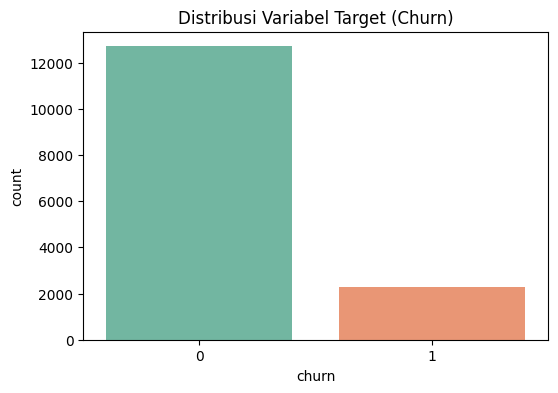

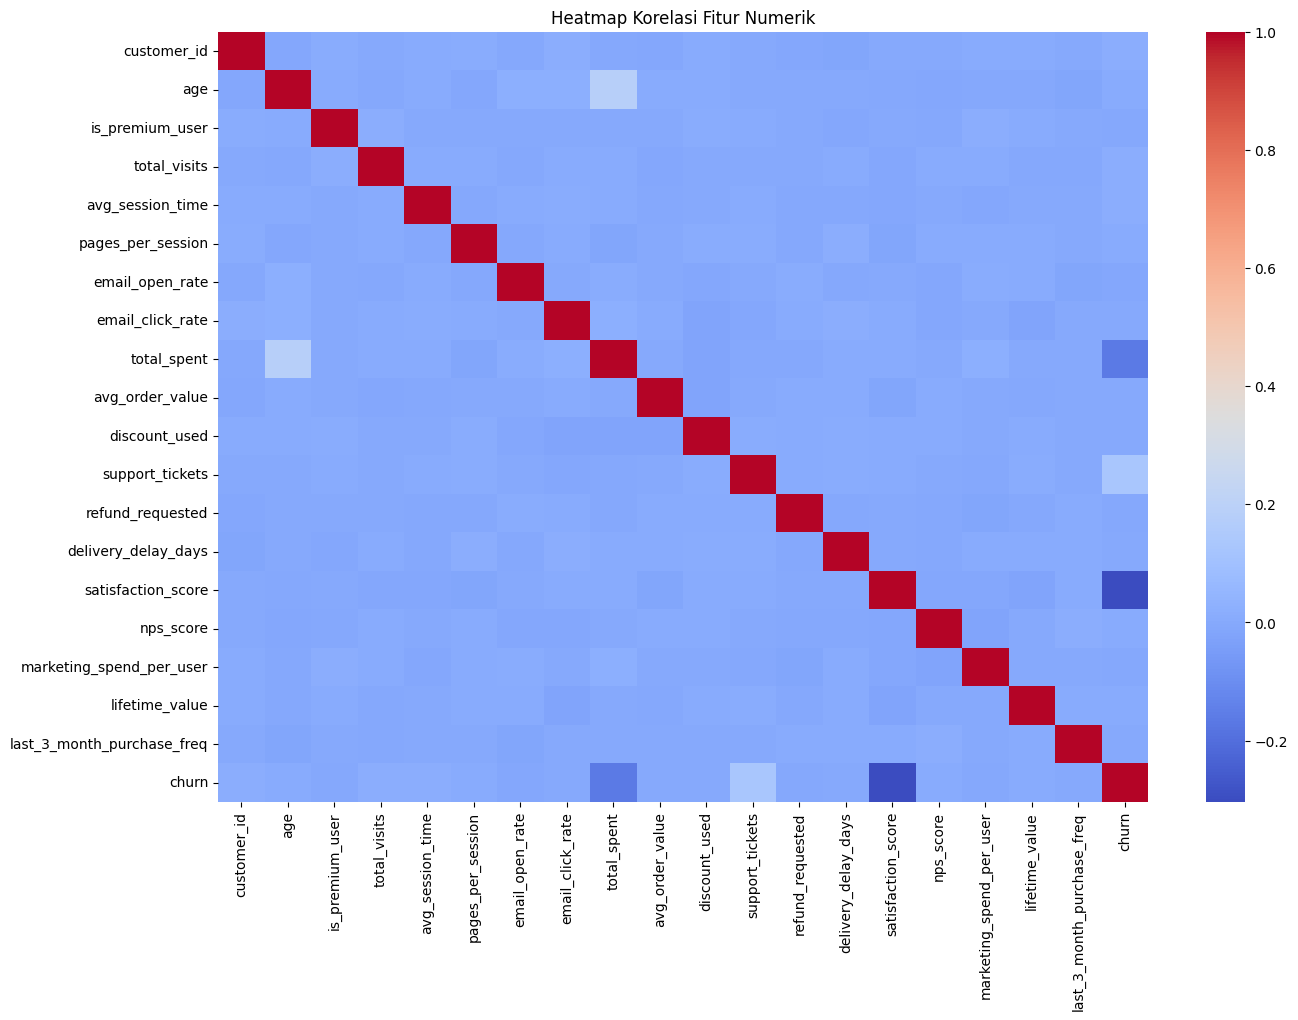

In [ ]:
print("=== Info Dataset ===")
df.info()

print("\n=== Missing Value ===")
print(df.isnull().sum())

# Visualisasi Distribusi Target (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, palette='Set2')
plt.title('Distribusi Variabel Target (Churn)')
plt.show()

# Heatmap Korelasi
plt.figure(figsize=(15, 10))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

### 2. Direct Modeling
Pemodelan tanpa preprocessing mendalam (Data non-numerik dibuang sementara, missing value diisi 0)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 2.1 Preprocessing instan untuk direct modeling
# Membuang baris yang mengandung missing value (tanpa diisi 0)
df_direct = numeric_df.dropna()

X_direct = df_direct.drop('churn', axis=1)
y_direct = df_direct['churn']

# 2.2 Train-test split
X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(X_direct, y_direct, test_size=0.2, random_state=42)

# 2.3 Mendefinisikan Model sesuai permintaan
models = {
    # Model Konvensional
    'Logistic Regression': LogisticRegression(max_iter=1000),

    # Model Ensemble Bagging
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),

    # Voting Classifier (LR + SVM + KNN)
    'Voting Classifier': VotingClassifier(estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('svm', SVC()),
        ('knn', KNeighborsClassifier())
    ], voting='hard')
}

# 2.4 & 2.5 Melatih dan Mengevaluasi Model
print("=== Hasil Evaluasi Direct Modeling (Update) ===\n")
for name, model in models.items():
    model.fit(X_train_dir, y_train_dir)
    y_pred = model.predict(X_test_dir)

    print(f"--- {name} ---")
    print(f"Accuracy  : {accuracy_score(y_test_dir, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test_dir, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_test_dir, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_test_dir, y_pred):.4f}\n")

=== Hasil Evaluasi Direct Modeling ===

--- Logistic Regression (Direct) ---
Accuracy  : 0.8371
Precision : 0.5660
Recall    : 0.1453
F1-Score  : 0.2312

--- SVM (Direct) ---
Accuracy  : 0.8314
Precision : 0.0000
Recall    : 0.0000
F1-Score  : 0.0000

--- KNN (Direct) ---
Accuracy  : 0.8273
Precision : 0.4658
Recall    : 0.1646
F1-Score  : 0.2433

--- Voting Classifier (Direct) ---
Accuracy  : 0.8335
Precision : 0.5758
Recall    : 0.0460
F1-Score  : 0.0852



### 3. Modeling dengan Preprocessing
Melakukan Handling Missing Value, Encoding, dan Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd # Pastikan pandas di-import untuk fungsi datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier, RandomForestClassifier

df_prep = df.copy()

# 3.1.a Penanganan Duplikasi
print("Jumlah duplikasi sebelum:", df_prep.duplicated().sum())
df_prep = df_prep.drop_duplicates()

# =======================================================
# 3.1.b FEATURE ENGINEERING (Rekayasa Fitur Baru)
# =======================================================
# 1. Ubah kolom menjadi format datetime
df_prep['signup_date'] = pd.to_datetime(df_prep['signup_date'], errors='coerce')
df_prep['last_purchase_date'] = pd.to_datetime(df_prep['last_purchase_date'], errors='coerce')

# 2. Buat fitur baru: tenure_days (Lama pelanggan menggunakan layanan dalam hitungan hari)
df_prep['tenure_days'] = (df_prep['last_purchase_date'] - df_prep['signup_date']).dt.days

# 3. Jika ada hasil perhitungan hari yang kosong (karena tanggalnya hilang), isi dengan median
df_prep['tenure_days'] = df_prep['tenure_days'].fillna(df_prep['tenure_days'].median())

# 4. Hapus fitur tanggal dan ID karena informasinya sudah berhasil diekstrak
df_prep = df_prep.drop(['customer_id', 'signup_date', 'last_purchase_date'], axis=1, errors='ignore')
print("Fitur baru 'tenure_days' berhasil ditambahkan!")
# =======================================================

# 3.1.c Penanganan Missing Value (Imputasi untuk sisa kolom)
for col in df_prep.columns:
    if df_prep[col].dtype == 'object':
        df_prep[col] = df_prep[col].fillna(df_prep[col].mode()[0])
    else:
        df_prep[col] = df_prep[col].fillna(df_prep[col].median())

# 3.1.d Penanganan Outlier (Menggunakan metode batas IQR/Capping)
numeric_cols = df_prep.select_dtypes(include=[np.number]).columns.drop('churn', errors='ignore')
for col in numeric_cols:
    Q1 = df_prep[col].quantile(0.25)
    Q3 = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping nilai pencilan (outlier)
    df_prep[col] = np.where(df_prep[col] > upper_bound, upper_bound,
                   np.where(df_prep[col] < lower_bound, lower_bound, df_prep[col]))

# =======================================================
# 3.1.e HYBRID ENCODING (Label Encoding + OHE)
# =======================================================
# 1. Label Encoding untuk data Ordinal dan Nominal dengan banyak kategori
le_cols = ['city', 'coupon_code', 'subscription_type']
for col in le_cols:
    if col in df_prep.columns:
        df_prep[col] = LabelEncoder().fit_transform(df_prep[col].astype(str))

# 2. One-Hot Encoding (OHE) untuk data Nominal dengan sedikit kategori
ohe_cols = ['gender', 'country', 'acquisition_channel', 'device_type', 'payment_method']
ohe_cols_existing = [col for col in ohe_cols if col in df_prep.columns]

# Menerapkan OHE (drop_first=False agar semua kategori utuh termasuk semua jenis gender dan negara)
df_prep = pd.get_dummies(df_prep, columns=ohe_cols_existing, drop_first=False)
print(f"Jumlah fitur/kolom setelah Hybrid Encoding: {df_prep.shape[1]}")
# =======================================================

# Menetapkan fitur (X) dan target (y)
X_prep = df_prep.drop('churn', axis=1)
y_prep = df_prep['churn']

# Train-test split
X_train_prep, X_test_prep, y_train_prep, y_test_prep = train_test_split(X_prep, y_prep, test_size=0.2, random_state=42)

# ==========================================
# 3.1.f PENERAPAN SMOTE (Hanya pada Data Training)
# ==========================================
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_prep, y_train_prep)

# 3.1.g Scaling (Sangat penting untuk SVM dan KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test_prep)

# 3.2 Mendefinisikan Model (Sesuai permintaan terbaru)
# Pastikan model ini di-inisialisasi sebelum loop evaluasi
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Voting Classifier': VotingClassifier(estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('svm', SVC()),
        ('knn', KNeighborsClassifier())
    ], voting='hard')
}

# 3.2 Evaluasi Model (Looping untuk setiap model yang didefinisikan)
print("\n=== Hasil Evaluasi Modeling dengan Preprocessing + SMOTE + Feature Engineering ===")
for name, model in models.items():
    # Melatih model menggunakan data training yang sudah di-SMOTE dan di-Scaling
    model.fit(X_train_scaled, y_train_smote)

    # Memprediksi data test (sudah di-scale)
    y_pred = model.predict(X_test_scaled)

    print(f"--- {name} ---")
    print(f"Accuracy  : {accuracy_score(y_test_prep, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test_prep, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_test_prep, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_test_prep, y_pred):.4f}\n")

Jumlah duplikasi sebelum: 0
Fitur baru 'tenure_days' berhasil ditambahkan!
Jumlah fitur/kolom setelah Hybrid Encoding: 44

=== Hasil Evaluasi Modeling dengan Preprocessing + SMOTE + Feature Engineering ===
--- Logistic Regression ---
Accuracy  : 0.8530
Precision : 0.5087
Recall    : 0.1982
F1-Score  : 0.2853

--- Random Forest ---
Accuracy  : 0.8523
Precision : 0.5011
Recall    : 0.5270
F1-Score  : 0.5137

--- Voting Classifier ---
Accuracy  : 0.8500
Precision : 0.4483
Recall    : 0.0586
F1-Score  : 0.1036



### 4. Hyperparameter Tuning & Feature Selection
Asumsi Random Forest adalah model terbaik, kita lakukan optimasi.

--- 1. Analisis Feature Importance ---


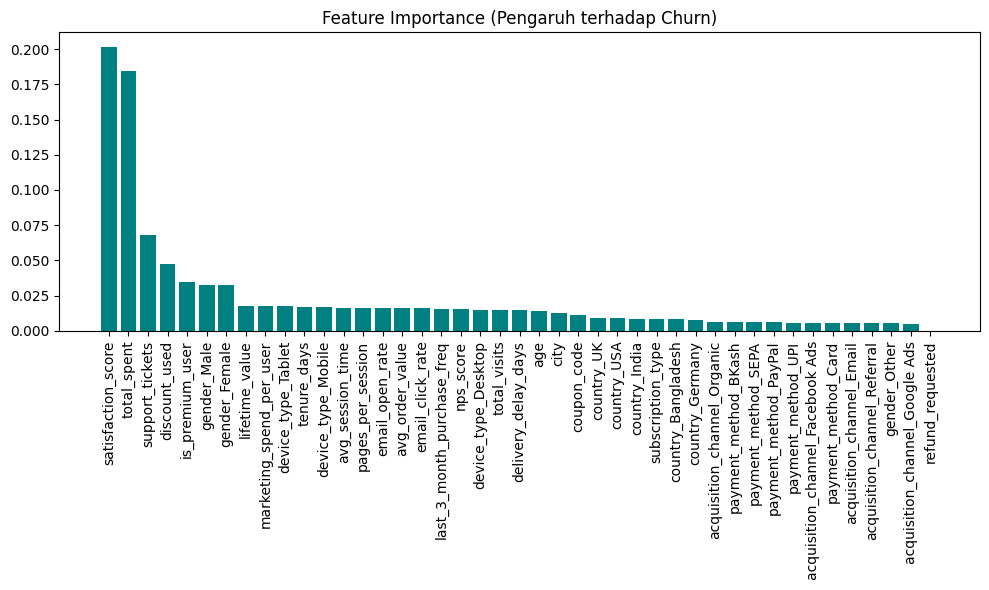


--- 2. Hyperparameter Tuning (Kompetisi 3 Strategi) ---
Sedang melakukan tuning pada: Model Konvensional (LR)...
Sedang melakukan tuning pada: Model Bagging (RF)...
Sedang melakukan tuning pada: Model Voting Classifier...

--- JUARA STRATEGI: Bagging (RF) ---
Best Parameters: {'max_depth': 10, 'n_estimators': 100}

--- 5. Melatih kembali Bagging (RF) dengan data latih optimal ---

--- 6. Evaluasi Performa Bagging (RF) ---
Accuracy  : 0.8470
Precision : 0.4878
Recall    : 0.6734
F1-Score  : 0.5658


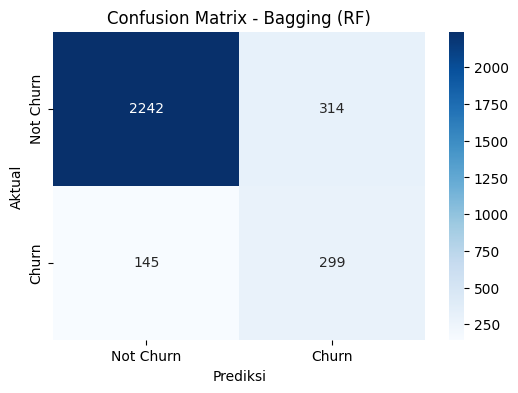


Model juara telah disimpan sebagai 'best_churn_model.pkl'!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# =====================================================================
# 1. Analisis Feature Importance (Menggunakan RF sebagai Explainer)
# =====================================================================
print("--- 1. Analisis Feature Importance ---")
rf_temp = RandomForestClassifier(random_state=42)
rf_temp.fit(X_train_scaled, y_train_smote)

importances = rf_temp.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_prep.columns

plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Pengaruh terhadap Churn)")
plt.bar(range(X_train_scaled.shape[1]), importances[indices], color='teal')
plt.xticks(range(X_train_scaled.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

# =====================================================================
# 2. Hyperparameter Tuning (Kompetisi 3 Strategi)
# =====================================================================
print("\n--- 2. Hyperparameter Tuning (Kompetisi 3 Strategi) ---")

# A. Konvensional (Logistic Regression)
model_a = LogisticRegression(max_iter=2000)
params_a = {'C': [0.1, 1, 10]}

# B. Ensemble Bagging (Random Forest)
model_b = RandomForestClassifier(random_state=42)
params_b = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10]}

# C. Voting Classifier (LR + SVM + KNN)
model_c = VotingClassifier(estimators=[
    ('lr', LogisticRegression(max_iter=2000)),
    ('svm', SVC(probability=True)),
    ('knn', KNeighborsClassifier())
], voting='soft', weights=[2, 1, 1])
params_c = {
    'weights': [[1, 1, 1], [2, 1, 1], [1, 2, 1]],
    'lr__C': [0.1, 1],
    'svm__C': [0.1, 1],
    # 'knn__n_neighbors': [3, 5]
}

def get_best_model(model, params, name):
    print(f"Sedang melakukan tuning pada: {name}...")
    grid = GridSearchCV(model, params, cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_train_scaled, y_train_smote)
    return grid.best_estimator_, grid.best_score_, grid.best_params_

best_a, score_a, param_a = get_best_model(model_a, params_a, "Model Konvensional (LR)")
best_b, score_b, param_b = get_best_model(model_b, params_b, "Model Bagging (RF)")
best_c, score_c, param_c = get_best_model(model_c, params_c, "Model Voting Classifier")

# =====================================================================
# 3 & 4. Penentuan Best Estimator
# =====================================================================
results = [('Konvensional (LR)', score_a, best_a, param_a),
           ('Bagging (RF)', score_b, best_b, param_b),
           ('Voting Classifier', score_c, best_c, param_c)]

best_strategy = max(results, key=lambda item: item[1])
print(f"\n--- JUARA STRATEGI: {best_strategy[0]} ---")
print(f"Best Parameters: {best_strategy[3]}")

# =====================================================================
# 5. Melatih Kembali (Refitting) Best Estimator
# =====================================================================
best_model_final = best_strategy[2]
print(f"\n--- 5. Melatih kembali {best_strategy[0]} dengan data latih optimal ---")
best_model_final.fit(X_train_scaled, y_train_smote)

# =====================================================================
# 6. Evaluasi Performa Model Optimal
# =====================================================================
print(f"\n--- 6. Evaluasi Performa {best_strategy[0]} ---")
y_pred_final = best_model_final.predict(X_test_scaled)

print(f"Accuracy  : {accuracy_score(y_test_prep, y_pred_final):.4f}")
print(f"Precision : {precision_score(y_test_prep, y_pred_final):.4f}")
print(f"Recall    : {recall_score(y_test_prep, y_pred_final):.4f}")
print(f"F1-Score  : {f1_score(y_test_prep, y_pred_final):.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_prep, y_pred_final), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_strategy[0]}')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

# Simpan model untuk Deployment
joblib.dump(best_model_final, 'best_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\nModel juara telah disimpan sebagai 'best_churn_model.pkl'!")


--- Tabel Perbandingan Metrik Evaluasi ---
            Model  Accuracy  Precision   Recall  F1-Score
Konvensional (LR)  0.852333   0.502959 0.191441  0.277325
     Bagging (RF)  0.847000   0.487765 0.673423  0.565752
Voting Classifier  0.853667   0.522523 0.130631  0.209009


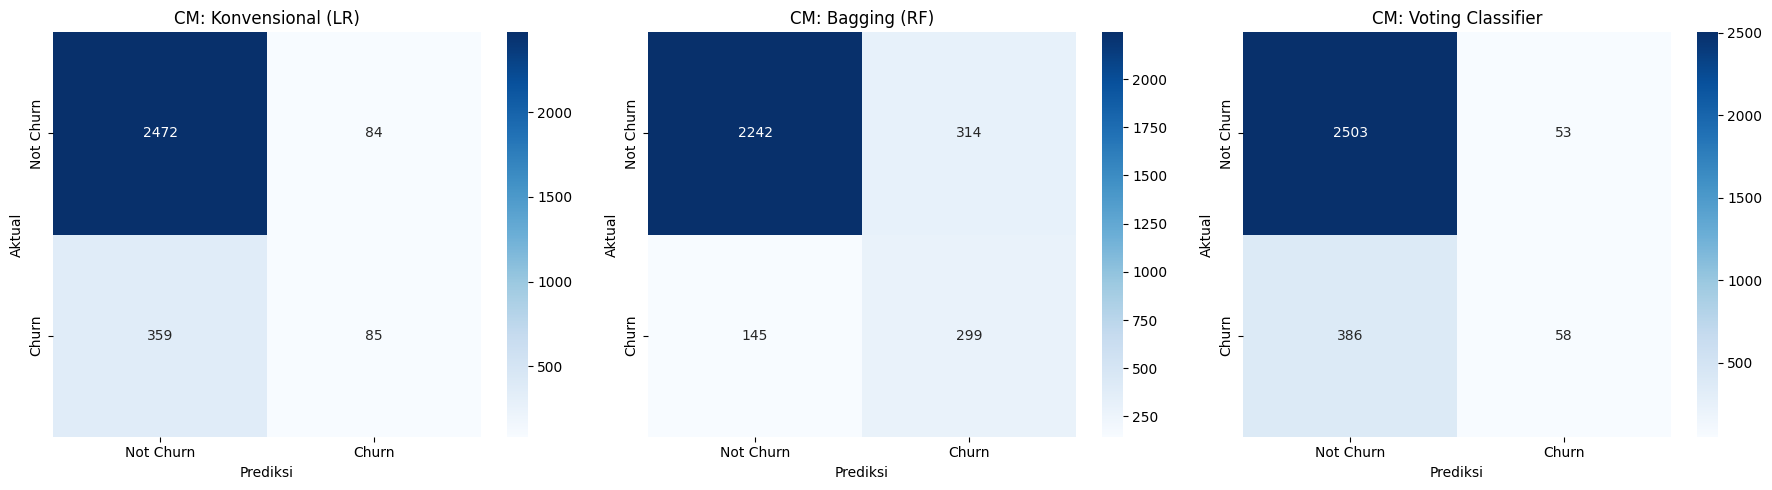

In [ ]:
# =====================================================================
# Evaluasi Perbandingan Menyeluruh (3 Model)
# =====================================================================
print("\n--- Tabel Perbandingan Metrik Evaluasi ---")

# Daftar model untuk dievaluasi
models_to_eval = [
    ('Konvensional (LR)', best_a),
    ('Bagging (RF)', best_b),
    ('Voting Classifier', best_c)
]

# List untuk menampung hasil
results_table = []

# Membuat plot untuk Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models_to_eval):
    y_pred = model.predict(X_test_scaled)

    # Menghitung Metrik
    acc = accuracy_score(y_test_prep, y_pred)
    prec = precision_score(y_test_prep, y_pred)
    rec = recall_score(y_test_prep, y_pred)
    f1 = f1_score(y_test_prep, y_pred)

    results_table.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

    # Plotting Confusion Matrix
    cm = confusion_matrix(y_test_prep, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Not Churn', 'Churn'],
                yticklabels=['Not Churn', 'Churn'])
    axes[i].set_title(f'CM: {name}')
    axes[i].set_xlabel('Prediksi')
    axes[i].set_ylabel('Aktual')

# Menampilkan Tabel
df_results = pd.DataFrame(results_table)
print(df_results.to_string(index=False))

plt.tight_layout()
plt.show()

### 5. Deployment: Menyimpan Model

In [ ]:
import joblib

# Simpan model juara dan scaler
joblib.dump(best_strategy[2], 'best_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model dan Scaler berhasil disimpan!")

Model dan Scaler berhasil disimpan!
